In [1]:
import sys
from IPython.display import display, Javascript

def restart_kernel():
    """Restart the Jupyter Notebook kernel to reflect changes in modules and packages."""
    display(Javascript("Jupyter.notebook.kernel.restart()"))
    print("Kernel is restarting...")

restart_kernel()

import numpy as np
import torch
import tensorly as tl
from tensorly.decomposition import parafac
import sparse
import pickle
import os
import numpy.random as rn
import scipy.stats as st
from tensorly.cp_tensor import CPTensor
import matplotlib.pyplot as plt

from own_implementation import BPTF as BPTF
import bptf

# Please run everything up to the first bptf fit
# Thereafter, run each following cell on their own

<IPython.core.display.Javascript object>

Kernel is restarting...


# Helper functions

In [2]:
def generate(shp=(30, 30, 20, 10), K=5, alpha=0.1, beta=0.1):
    """Generate a count tensor from the BPTF model.

    PARAMS:
    shp -- (tuple) shape of the generated count tensor
    K -- (int) number of latent components
    alpha -- (float) shape parameter of gamma prior over factors
    beta -- (float) rate parameter of gamma prior over factors

    RETURNS:
    Mu -- (np.ndarray) true Poisson rates
    Y -- (np.ndarray) generated count tensor
    """
    Theta_DK_M = [rn.gamma(alpha, 1./beta, size=(D, K)) for D in shp]
    Theta_DK_M = [torch.tensor(factor) for factor in Theta_DK_M]
    Mu = tl.cp_to_tensor(CPTensor((None, Theta_DK_M)))
    assert Mu.shape == shp
    Y = rn.poisson(Mu)
    return Mu, Y

# Load data

In [3]:
use_existing_data = True

# for the first bptf.fit:
# using seed 100 causes the assert delta >= 0 to trip
# but using seed 0 doesn't
# please swap between the 2 seeds to get the 2 different types of assertion errors in the other cells
rn.seed(100)
device = 'cuda'

if use_existing_data:
    assert os.path.exists('sptensor.pkl'), 'No such file.'
    with open('sptensor.pkl', 'rb') as f:
        data = pickle.load(f)
    data = data[:, :, :, :12, :]
    data = torch.tensor(data.todense(), dtype=torch.float64, device=device)
else:
    data = generate(shp=(200, 200, 20, 12, 3), K=10)[1]
    data = torch.tensor(data, dtype=torch.float64, device=device)

# Building mask (base example)

In [4]:
mask = np.ones(data.shape)
# april of GDELT is set to missing
mask[:, :, :, 3, 1] = 0

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 0
mask = torch.tensor(mask.astype(np.int64), dtype=torch.float64, device=device)

# Fit model

ELBO = 12135061.98383766, change = 8.654060047958419e-08, time taken = 3.019080638885498: 100%|██████████| 500/500 [24:53<00:00,  2.99s/it]   

Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-2843353180.5990787, 5178186.32706874, 5337111.308869723, 5857954.656489384, 6963428.877976586, 8067497.1448089415, 9109799.666501712, 9899255.447179466, 10392427.901873574, 10727315.635506844, 10967565.874028577, 11143719.755941696, 11287079.523812037, 11411890.674083645, 11516762.042100586, 11597962.68619039, 11662673.439904321, 11728043.504969744, 11785934.790478544, 11821146.105105883, 11848808.28134342, 11872312.556166038, 11892778.523991257, 11910842.24442797, 11926950.076522565, 11941404.37948474, 11954389.749270886, 11965996.194466185, 11976288.426087214, 11985381.182959845, 11993377.469530972, 12000503.918481322, 12006937.685968658, 12012764.339663114, 12018144.43494016, 12023153.065589974, 12027843.631301144, 12032267.090521563, 12036453.204186581, 12040407.698396612, 12044136.857350204, 12047652.198906152, 12050954.72578341, 12054055.45975921, 12056987.36250614, 12059789.17988975,

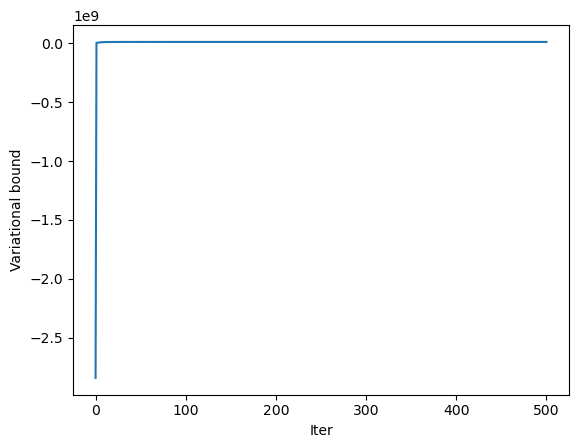

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([280, 280, 20, 12, 3]), device='cuda',
     n_components=50)

In [5]:
n_components = 50
max_iter = 500
tol = 1e-10

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=True, tol=tol)

# Mask with last mode completely masked

ELBO = 12148895.768720029, change = 5.784075439458114e-08, time taken = 3.035055637359619: 100%|██████████| 500/500 [25:15<00:00,  3.03s/it]  

Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-2730515217.8110347, 5299969.630562569, 5397725.410527017, 5793374.336046728, 6691059.905623715, 7824279.261550587, 8972337.203432651, 9927519.538933123, 10542999.343221027, 10905762.573345406, 11141183.97967168, 11311141.695552235, 11439575.104548207, 11537264.7513395, 11614233.593580527, 11677874.254654484, 11730739.752499364, 11773932.395380894, 11808918.557404581, 11837348.578484165, 11860644.10632045, 11880073.08921226, 11896584.79069319, 11910855.137857242, 11923508.032105979, 11935098.328056823, 11946078.333299952, 11956759.142218677, 11967230.868534282, 11977356.57078045, 11986908.857975243, 11995843.158504702, 12004177.331560668, 12012045.505263586, 12019675.650536176, 12027364.25621724, 12035242.053719515, 12042977.602223763, 12050051.242412446, 12056207.291725043, 12061484.592574745, 12066091.307009067, 12070241.412281962, 12074106.256042538, 12077730.423700148, 12081220.47701826,

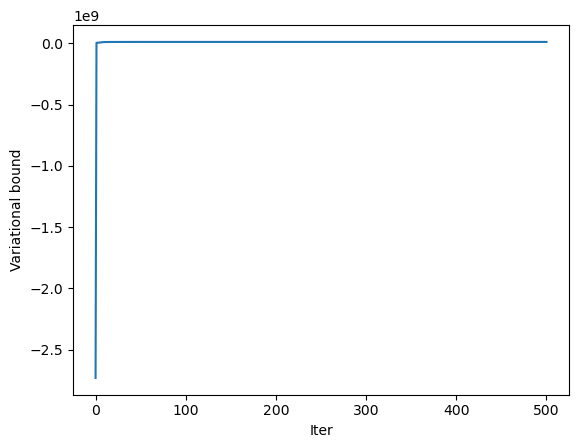

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([280, 280, 20, 12, 3]), device='cuda',
     n_components=50)

In [6]:
mask = np.ones(data.shape)
# april of GDELT is set to missing
mask[:, :, :, 3, :] = 0

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 0
mask = torch.tensor(mask.astype(np.int64), dtype=torch.float64, device=device)

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=True, tol=tol)

# Mask with the 1st and 3rd indices masked

ELBO = 13455492.615464969, change = 5.2829405917923334e-08, time taken = 3.0001208782196045: 100%|██████████| 500/500 [25:07<00:00,  3.02s/it]

Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-2730065041.1444073, 5713880.738759422, 6120109.521558478, 6547843.789113279, 7677586.003784243, 8897757.879983181, 10016818.915551625, 10911059.238515785, 11522813.623416336, 11931298.402916465, 12220189.642462699, 12432215.121250667, 12591400.565616751, 12715894.982774515, 12814976.263709795, 12893541.519553307, 12956330.10754309, 13007493.663708696, 13050063.288592655, 13085618.249735707, 13115472.687596628, 13141530.196377596, 13165212.377105722, 13187470.514057007, 13208862.79191308, 13229599.93863813, 13249272.099378316, 13266731.956712322, 13281119.173992813, 13293133.877068957, 13303367.188403621, 13312160.642793218, 13320014.243286798, 13327214.133812787, 13333924.597548658, 13340244.644154437, 13346235.435985649, 13351913.06759127, 13357270.909588076, 13362298.68463173, 13366978.227201078, 13371236.134697827, 13375069.84087121, 13378489.653814731, 13381538.921989592, 13384269.70034

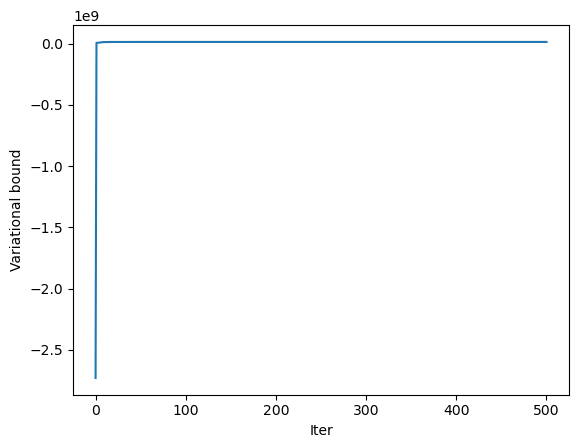

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([280, 280, 20, 12, 3]), device='cuda',
     n_components=50)

In [7]:
mask = np.ones(data.shape)
# april is set to missing
mask[:, :, :, 3, [0, 2]] = 0

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 0
mask = torch.tensor(mask.astype(np.int64), dtype=torch.float64, device=device)

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=True, tol=tol)

# Mask with only diagonals masked

ELBO = 13396530.790630873, change = 2.4864212428777585e-07, time taken = 2.9751381874084473: 100%|██████████| 500/500 [24:48<00:00,  2.98s/it]

Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-2987862263.5965033, 5940859.339303671, 6051437.255789905, 6526822.037012198, 7657700.002832504, 8928750.165245008, 9989106.494780282, 10869891.168784807, 11520497.179223811, 11936377.524191512, 12204767.478736615, 12392950.229569223, 12538931.634378228, 12661664.85649202, 12765890.083906291, 12849646.322995357, 12916660.16498389, 12972021.642915064, 13018905.614260301, 13057987.100084882, 13089748.384112658, 13115859.528864523, 13138822.856265781, 13162072.26691242, 13189000.206950117, 13214619.47856987, 13233012.416846741, 13246820.455285465, 13258060.168409344, 13267474.369341988, 13275623.985619564, 13283128.818497213, 13289666.351949524, 13295316.877413005, 13300479.754005665, 13305674.981949585, 13310384.078153688, 13314337.268990487, 13317971.174389943, 13321326.833313555, 13324473.115525706, 13327445.851006225, 13330263.841591965, 13332909.732107848, 13335410.4078629, 13337760.231170

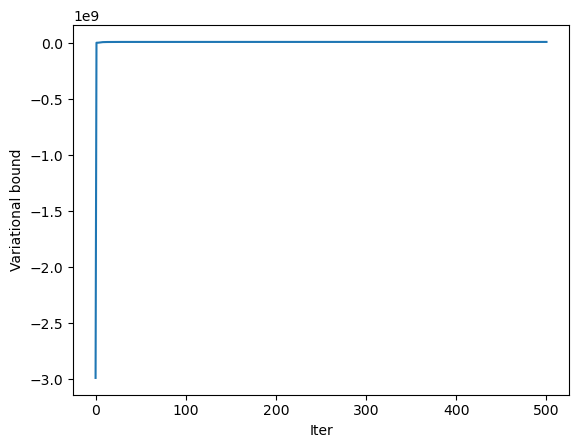

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([280, 280, 20, 12, 3]), device='cuda',
     n_components=50)

In [8]:
mask = np.ones(data.shape)

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 0
mask = torch.tensor(mask.astype(np.int64), dtype=torch.float64, device=device)

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=True, tol=tol)

# No mask

ELBO = 19205742.726655252, change = 4.1188448402479075e-08, time taken = 2.693533182144165: 100%|██████████| 500/500 [22:48<00:00,  2.74s/it] 

Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-2900964778.6371174, 8316119.48399659, 8503533.892951217, 9225839.774844501, 10956706.397871798, 13438943.313821884, 15398614.151748994, 16577424.63621277, 17295694.077016994, 17759759.012347315, 18064190.241279867, 18277925.896086957, 18431673.06046608, 18541089.0767659, 18620557.542572215, 18681899.09484476, 18732142.545878638, 18775360.512399998, 18813697.28367423, 18847284.52244273, 18875556.903364222, 18898807.324112173, 18918130.88797672, 18934766.53882376, 18949876.97067534, 18964033.723288365, 18977550.19743609, 18990414.25381475, 19002260.06471409, 19012781.43516085, 19022124.0629827, 19030602.31451885, 19038641.393032413, 19046760.505698096, 19055721.34430343, 19066502.063245136, 19079114.577040788, 19090211.132424653, 19097173.128697302, 19102523.609826118, 19107901.608377628, 19112702.615221284, 19117103.35077703, 19121304.770409565, 19125487.349345826, 19129737.829168264, 191340

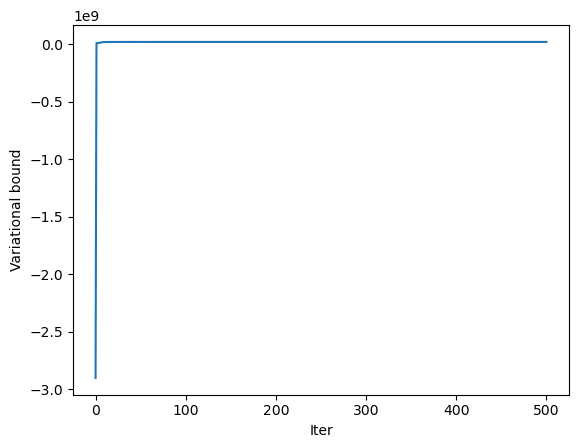

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([280, 280, 20, 12, 3]), device='cuda',
     n_components=50)

In [9]:
BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = None, max_iter = max_iter, verbose=True, tol=tol)